<div style="background: linear-gradient(135deg, #1a237e 0%, #283593 50%, #3949ab 100%); padding: 40px 35px; border-radius: 12px; color: white; margin-bottom: 10px;">
<h1 style="margin:0 0 8px 0; font-size: 2.2em; font-weight: 800; letter-spacing: -0.5px;">📊 Telecom X — Part 2</h1>
<h2 style="margin:0 0 20px 0; font-size: 1.3em; font-weight: 400; opacity: 0.9;">Customer Cancellation Prediction (Churn)</h2>
<hr style="border: none; border-top: 1px solid rgba(255,255,255,0.3); margin: 16px 0;">
<p style="margin:0; font-size: 1em; opacity: 0.85; line-height: 1.7;">
In this second stage of the challenge, we developed a complete Machine Learning pipeline to predict which customers are most likely to cancel their service. The data treated in Part 1 is used, guaranteeing consistency and quality in the analysis.
</p>
</div>

<div style="display: flex; gap: 12px; flex-wrap: wrap; margin-top: 16px;">
<div style="flex:1; min-width:150px; background:#e8eaf6; border-left: 4px solid #3949ab; border-radius: 8px; padding: 14px 18px;">
<div style="font-size:1.3em;">🛠️</div>
<div style="font-weight:700; margin: 4px 0 2px;">Preparation</div>
<div style="font-size:0.85em; color:#555;">Cleaning, encoding and normalization</div>
</div>
<div style="flex:1; min-width:150px; background:#e8f5e9; border-left: 4px solid #388e3c; border-radius: 8px; padding: 14px 18px;">
<div style="font-size:1.3em;">🎯</div>
<div style="font-weight:700; margin: 4px 0 2px;">Correlation</div>
<div style="font-size:0.85em; color:#555;">Selection of relevant variables</div>
</div>
<div style="flex:1; min-width:150px; background:#fff3e0; border-left: 4px solid #f57c00; border-radius: 8px; padding: 14px 18px;">
<div style="font-size:1.3em;">🤖</div>
<div style="font-weight:700; margin: 4px 0 2px;">Modeling</div>
<div style="font-size:0.85em; color:#555;">Logistic Regression + Random Forest</div>
</div>
<div style="flex:1; min-width:150px; background:#fce4ec; border-left: 4px solid #c62828; border-radius: 8px; padding: 14px 18px;">
<div style="font-size:1.3em;">📋</div>
<div style="font-weight:700; margin: 4px 0 2px;">Conclusions</div>
<div style="font-size:0.85em; color:#555;">Insights and retention strategies</div>
</div>
</div>

---
## 📦 1. Bookstore Import

We load all the necessary libraries for exploratory analysis, preprocessing and predictive modeling.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')


---
## 📂 2. Data Upload

We load the dataset discussed in **Part 1** of the challenge. This file already contains clean, standardized data without irrelevant columns.

In [40]:
# We load the dataset discussed in Part 1
df = pd.read_csv("datos_tratados.csv")

print(f"Shape del dataset: {df.shape}")
df.head()

Shape del dataset: (7256, 21)


,Churn,gender,Adulto_Mayor,Partner,Dependents,Antiguedad_Meses,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0.0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0.0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1.0,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1.0,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1.0,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7032 non-null   float64
 1   gender            7256 non-null   object 
 2   Adulto_Mayor      7256 non-null   int64  
 3   Partner           7256 non-null   int64  
 4   Dependents        7256 non-null   int64  
 5   Antiguedad_Meses  7256 non-null   int64  
 6   PhoneService      7256 non-null   int64  
 7   MultipleLines     7256 non-null   object 
 8   InternetService   7256 non-null   object 
 9   OnlineSecurity    7256 non-null   object 
 10  OnlineBackup      7256 non-null   object 
 11  DeviceProtection  7256 non-null   object 
 12  TechSupport       7256 non-null   object 
 13  StreamingTV       7256 non-null   object 
 14  StreamingMovies   7256 non-null   object 
 15  Contract          7256 non-null   object 
 16  Factura_Digital   7256 non-null   int64  


In [42]:
df.describe()

,Churn,Adulto_Mayor,Partner,Dependents,Antiguedad_Meses,PhoneService,Factura_Digital,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158467
std,0.441782,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004282
min,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.180000
50%,0.000000,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.340000
75%,1.000000,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,3.000000
max,1.000000,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


---
## 🛠️ 3. Data Preparation

Before training any model, it is necessary to properly prepare the dataset: clean null values ​​in the target variable, encode categorical variables, check class balance, and apply normalization as appropriate.

### 3.1 Initial Cleaning

In [43]:
# We delete rows with null values ​​in the target variable
df = df.dropna(subset=["Churn"])

# We convert Churn to integer
df["Churn"] = df["Churn"].astype(int)

print(f"Registros después de limpieza: {len(df)}")
print(f"Valores nulos en Churn: {df['Churn'].isnull().sum()}")

Registros después de limpieza: 7032
Valores nulos en Churn: 0


### 3.2 Elimination of Irrelevant Columns

The dataset was reviewed for columns that do not provide predictive value, such as unique identifiers (e.g. customer ID).

> ✅ In this treated dataset **no identification columns** or irrelevant variables were identified. All variables represent customer or service characteristics, so **no columns were removed** at this stage.

### 3.3 Encoding of Categorical Variables

Machine Learning algorithms require that all inputs be numerical. We apply **One-Hot Encoding** to transform the text type variables.

In [44]:
# We identify categorical columns
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Columnas categóricas:", cat_cols)

Columnas categóricas: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'Metodo_Pago']


In [45]:
# We separate features (X) and objective variable (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# We apply One-Hot Encoding with drop_first=True to avoid multicollinearity
X = pd.get_dummies(X, drop_first=True)

print(f"Shape de X luego del encoding: {X.shape}")
X.head()

Shape de X luego del encoding: (7032, 31)


,Adulto_Mayor,Partner,Dependents,Antiguedad_Meses,PhoneService,Factura_Digital,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,1,1,9,1,1,65.6,593.30,2.19,False,...,True,False,True,False,False,True,False,False,False,True
1,0,0,0,9,1,0,59.9,542.40,2.00,True,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,4,1,1,73.9,280.85,2.46,True,...,False,False,False,False,False,False,False,False,True,False
3,1,1,0,13,1,1,98.0,1237.85,3.27,True,...,False,False,True,False,True,False,False,False,True,False
4,1,1,0,3,1,1,83.9,267.40,2.80,False,...,True,False,True,False,False,False,False,False,False,True


> 💡 **Why `drop_first=True`?**
> When creating dummy variables, one of the categories is redundant (if all others are 0, it is automatically inferred). Using `drop_first=True` avoids the **dummy variable trap** (perfect multicollinearity), improving model stability.

### 3.4 Churn Ratio Verification

Before training the models, we check the class balance. An extreme imbalance can bias the model towards the majority class.

Distribución de clases:
  Clientes que permanecen (0): 73.42%
  Clientes que cancelaron  (1): 26.58%


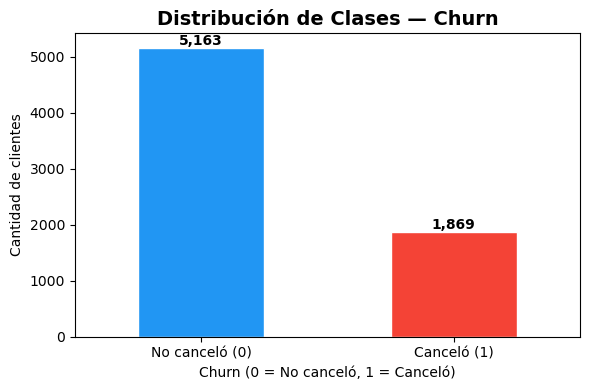

In [46]:
# We calculate the proportion of customers who canceled vs. those who remain
proporcion = y.value_counts(normalize=True)

print("Distribución de clases:")
print(f"  Clientes que permanecen (0): {proporcion[0]*100:.2f}%")
print(f"  Clientes que cancelaron  (1): {proporcion[1]*100:.2f}%")

# Display
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["# 2196F3", "#F44336"]
y.value_counts().plot(kind="bar", ax=ax, color=colors, edgecolor="white", width=0.5)
ax.set_title("Distribución de Clases — Churn", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn (0 = No canceló, 1 = Canceló)")
ax.set_ylabel("Cantidad de clientes")
ax.set_xticklabels(["No canceló (0)", "Canceló (1)"], rotation=0)
for i, v in enumerate(y.value_counts()):
    ax.text(i, v + 50, f"{v:,}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background: #fff8e1; border-left: 4px solid #f9a825; border-radius: 6px; padding: 14px 18px; margin: 4px 0;">
<strong>⚖️ Analysis of Class Imbalance</strong><br><br>
The dataset presents approximately <strong>73.4% of active customers</strong> and <strong>26.6% of customers who canceled</strong>.<br><br>
Although there is an imbalance, <em>it is not considered extreme</em>. In this first stage, balancing techniques (SMOTE, oversampling, undersampling) will not be applied. If the models present low <strong>Recall</strong> in the positive class, their application will be evaluated in a subsequent iteration.
</div>

### 3.5 Data Separation (Train / Test)

We divide the dataset into training and test sets. An **80% / 20%** split provides sufficient data for learning and representative evaluation.

In [47]:
# Division 80% training / 20% test with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Maintains churn ratios in both sets
)

print(f"Tamaño Train: {X_train.shape[0]} registros")
print(f"Tamaño Test:  {X_test.shape[0]} registros")
print(f"\nDistribución Churn en Train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribución Churn en Test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Tamaño Train: 5625 registros
Tamaño Test:  1407 registros

Distribución Churn en Train: {0: 0.734, 1: 0.266}
Distribución Churn en Test:  {0: 0.734, 1: 0.266}


> 🔒 **Good practices applied:**
> - `stratify=y` ensures that both sets maintain the same proportion of classes (≈26.6% churn).
> - The split was done **before** scaling to avoid *data leakage* — the model should not "know" the test data during training.

### 3.6 Normalization / Standardization

Not all models require scaling. We apply `StandardScaler` exclusively for the **Logistic Regression** model.

In [48]:
# We scale for the Logistic Regression model (scale sensitive)
scaler = StandardScaler()

# fit ONLY on train — avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Datos estandarizados (media=0, desv. estándar=1)")
print(f"Media de columna 'Cargo_Mensual' en train escalado: {X_train_scaled[:, list(X.columns).index('Cargo_Mensual')].mean():.4f}")

✅ Datos estandarizados (media=0, desv. estándar=1)
Media de columna 'Cargo_Mensual' en train escalado: -0.0000


<div style="display:flex; gap:12px; margin: 4px 0;">
<div style="flex:1; background:#e8f5e9; border-radius:8px; padding:14px 16px;">
<strong>✅ Logistic Regression</strong><br>
<span style="font-size:0.9em;">Scale sensitive. Standardization guarantees that all variables contribute equally to the model.</span>
</div>
<div style="flex:1; background:#f3e5f5; border-radius:8px; padding:14px 16px;">
<strong>🌳 Random Forest</strong><br>
<span style="font-size:0.9em;">No scaling required. Trees work with thresholds and divisions, regardless of the magnitude of the variables.</span>
</div>
</div>

> ⚠️ The `StandardScaler` is adjusted (`fit`) **only** on the training data and then applied (`transform`) to the test. This prevents *data leakage*.

---
## 🎯 4. Correlation Analysis and Variable Selection

We analyzed the relationships between numerical variables and the target variable (`Churn`) to identify the most relevant predictors before modeling.

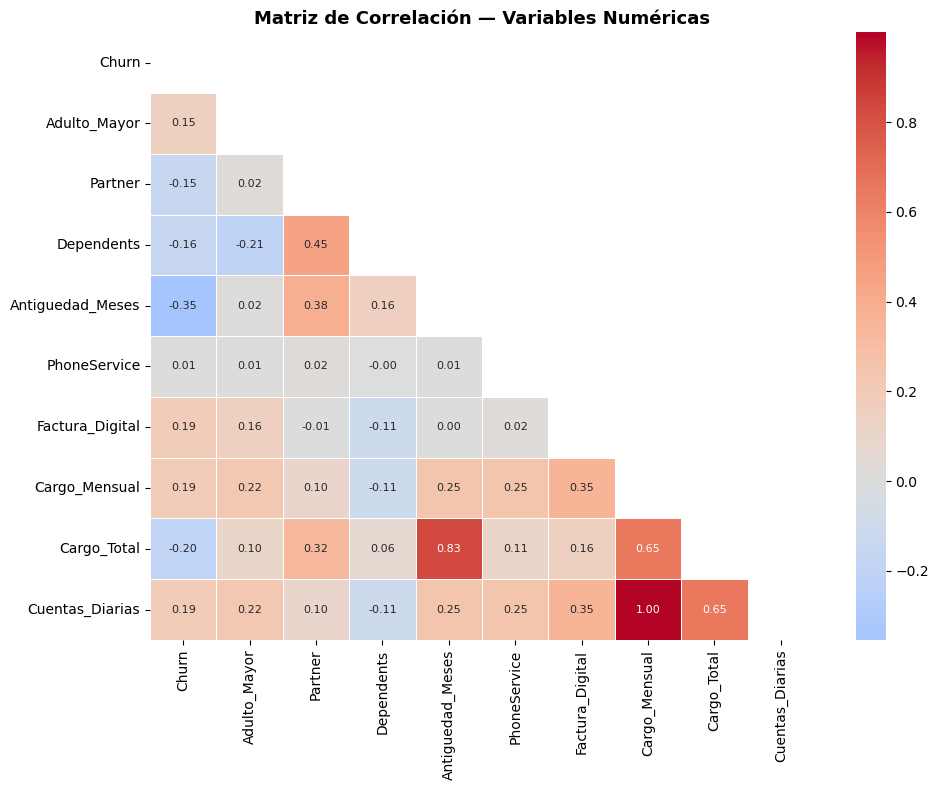

In [49]:
# Correlation matrix of original numerical variables
corr_num = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_num, dtype=bool))
sns.heatmap(
    corr_num, mask=mask, cmap="coolwarm", center=0,
    annot=True, fmt=".2f", linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Matriz de Correlación — Variables Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [50]:
# Correlation of all variables with Churn
corr_churn = df.corr(numeric_only=True)["Churn"].sort_values(ascending=False).drop("Churn")

print("Correlación de variables con Churn:\n")
print(corr_churn.round(4))

Correlación de variables con Churn:

Cuentas_Diarias     0.1929
Cargo_Mensual       0.1929
Factura_Digital     0.1915
Adulto_Mayor        0.1505
PhoneService        0.0117
Partner            -0.1500
Dependents         -0.1631
Cargo_Total        -0.1995
Antiguedad_Meses   -0.3540
Name: Churn, dtype: float64


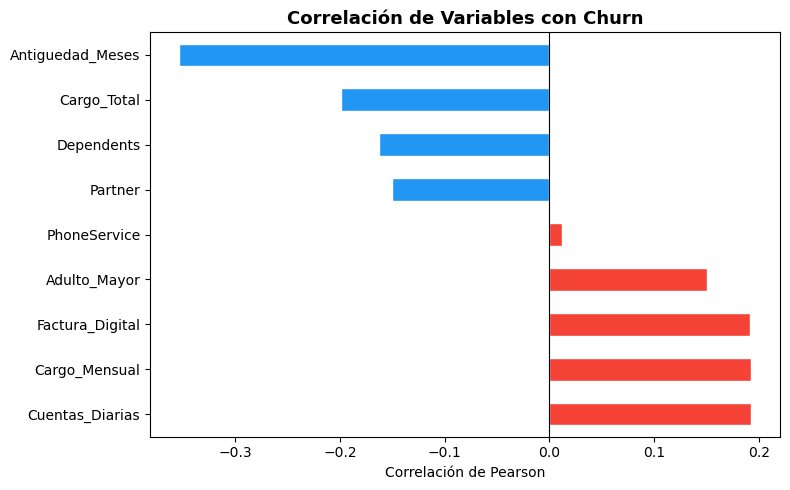

In [51]:
# Correlation graph with Churn
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["# F44336" if v > 0 else "#2196F3" for v in corr_churn.values]
corr_churn.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de Variables con Churn", fontsize=13, fontweight="bold")
ax.set_xlabel("Correlación de Pearson")
plt.tight_layout()
plt.show()

<div style="background: #e3f2fd; border-left: 4px solid #1565c0; border-radius: 6px; padding: 14px 18px; margin: 4px 0;">
<strong>📌 Main findings of the correlation matrix:</strong>
<ul style="margin: 8px 0 0 0; padding-left: 20px; line-height: 1.8;">
<li><code>Seniority_Months</code> presents the highest <strong>negative correlation (−0.35)</strong>: the longer the tenure, the lower the risk of churn.</li>
<li><code>Monthly_Charge</code> and <code>Daily_Accounts</code> show <strong>positive correlation (~0.19)</strong>: higher costs are associated with greater abandonment.</li>
<li><code>Partner</code> and <code>Dependents</code> have a negative correlation: clients with families have greater stability.</li>
<li>No correlations > 0.7 were detected between independent variables, so <strong>there is no serious multicollinearity</strong> at this stage.</li>
</ul>
</div>

### 4.1 Directed Analysis — Key Variables vs Cancellation

We delve deeper into the variables most correlated with churn using specific visualizations: **boxplots** to compare distributions and **scatter plot** to observe the interaction between seniority and spending.

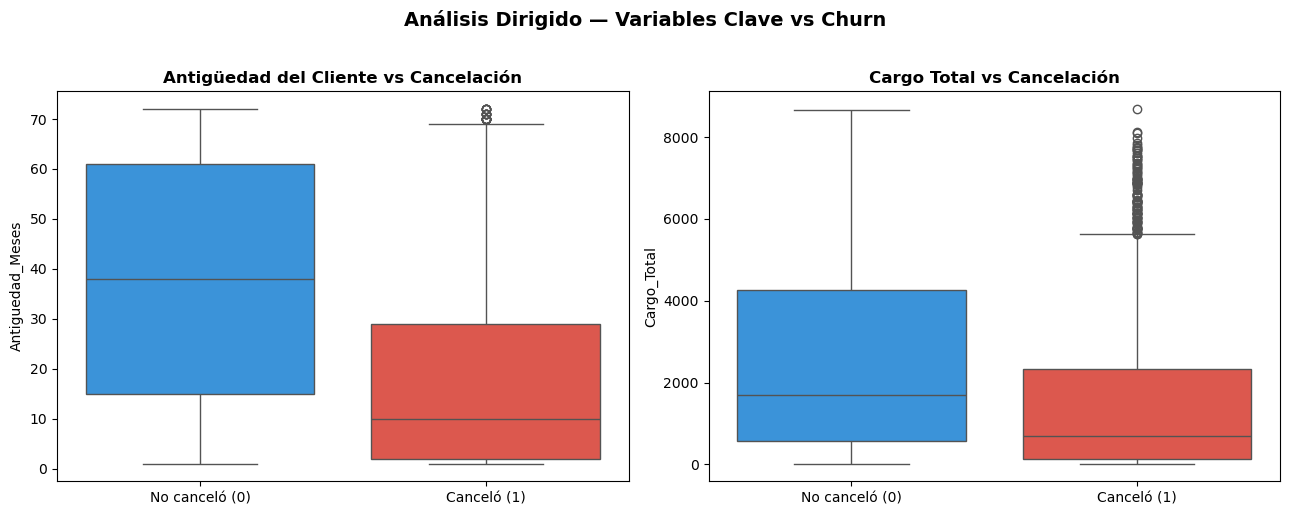

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot: Age vs Churn
sns.boxplot(x="Churn", y="Antiguedad_Meses", data=df, ax=axes[0],
            palette={'0': "# 2196F3", '1': "#F44336"})
axes[0].set_title("Antigüedad del Cliente vs Cancelación", fontweight="bold")
axes[0].set_xticklabels(["No canceló (0)", "Canceló (1)"])
axes[0].set_xlabel("")

# Boxplot: Total Charge vs Churn
sns.boxplot(x="Churn", y="Cargo_Total", data=df, ax=axes[1],
            palette={'0': "# 2196F3", '1': "#F44336"})
axes[1].set_title("Cargo Total vs Cancelación", fontweight="bold")
axes[1].set_xticklabels(["No canceló (0)", "Canceló (1)"])
axes[1].set_xlabel("")

plt.suptitle("Análisis Dirigido — Variables Clave vs Churn", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

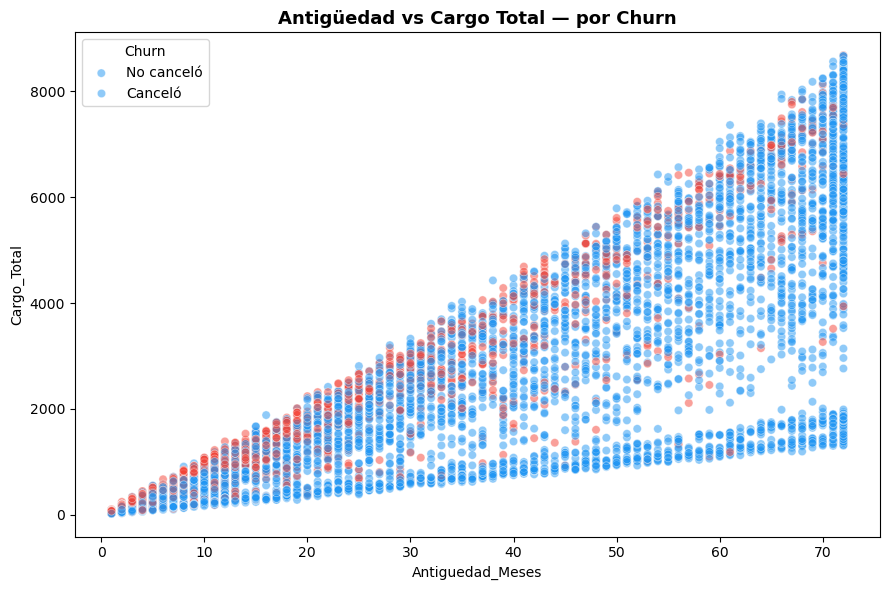

In [53]:
# Scatter plot: Seniority vs Total Charge colored by Churn
plt.figure(figsize=(9, 6))
scatter = sns.scatterplot(
    x="Antiguedad_Meses", y="Cargo_Total",
    hue="Churn", data=df, alpha=0.5,
    palette={0: "# 2196F3", 1: "#F44336"},
    legend="full"
)
plt.title("Antigüedad vs Cargo Total — por Churn", fontsize=13, fontweight="bold")
plt.legend(title="Churn", labels=["No canceló", "Canceló"])
plt.tight_layout()
plt.show()

<div style="background: #f9fbe7; border-left: 4px solid #827717; border-radius: 6px; padding: 14px 18px; margin: 4px 0;">
<strong>📊 Visual analysis observations:</strong>
<ul style="margin: 8px 0 0 0; padding-left: 20px; line-height: 1.8;">
<li>Customers who <strong>cancel</strong> have on average <em>lower seniority</em> and <em>lower total accumulated charge</em> — logically related to their short tenure.</li>
<li>Customers who <strong>remain</strong> show broader distributions, with greater dispersion in both variables.</li>
<li>The scatter plot confirms that churners are concentrated in the area of ​​<strong>low seniority + low total charge</strong>: they are new customers who have not yet accumulated value.</li>
</ul>
</div>

---
## 🤖 5. Predictive Modeling

We train two classification models with complementary approaches:

| Model | Requires Scaling | Interpretability | Type |
|---|:---:|:---:|---|
| **Logistic Regression** | ✅ Yes | ⭐⭐⭐ High | Linear |
| **Random Forest** | ❌ No | ⭐⭐ Media | Tree-based |

### 5.1 Model 1 — Logistic Regression
*Linear, interpretable and robust model. Use scaled data.*

In [54]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
print("✅ Modelo de Regresión Logística entrenado")

✅ Modelo de Regresión Logística entrenado


### 5.2 Model 2 — Random Forest
*Ensemble of decision trees. Captures non-linear relationships and provides importance of variables. Use unscaled data.*

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("✅ Modelo Random Forest entrenado")

✅ Modelo Random Forest entrenado


---
## 📊 6. Model Evaluation

We evaluate each model with standard ranking metrics. For the **churn** problem, **Recall** is especially important: we prefer to detect all at-risk clients, even if we incur some false positives.

### 6.1 Logistic Regression — Metrics

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("=" * 45)
print("       REGRESIÓN LOGÍSTICA")
print("=" * 45)
print(f"  Accuracy : {accuracy_score(y_test, y_pred_log):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_log):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_log):.4f}")
print()
print("Reporte Completo:")
print(classification_report(y_test, y_pred_log, target_names=["No Churn", "Churn"]))

       REGRESIÓN LOGÍSTICA
  Accuracy : 0.8010
  Precision: 0.6556
  Recall   : 0.5294
  F1-Score : 0.5858

Reporte Completo:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



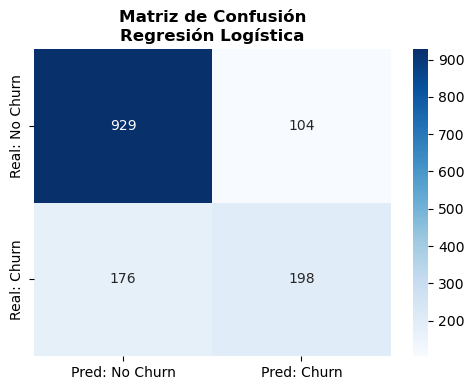

In [57]:
# Confusion matrix — Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No Churn", "Pred: Churn"],
            yticklabels=["Real: No Churn", "Real: Churn"])
plt.title("Matriz de Confusión\nRegresión Logística", fontweight="bold")
plt.tight_layout()
plt.show()

### 6.2 Random Forest — Metrics

In [58]:
print("=" * 45)
print("           RANDOM FOREST")
print("=" * 45)
print(f"  Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_rf):.4f}")
print()
print("Reporte Completo:")
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))

           RANDOM FOREST
  Accuracy : 0.7875
  Precision: 0.6335
  Recall   : 0.4759
  F1-Score : 0.5435

Reporte Completo:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



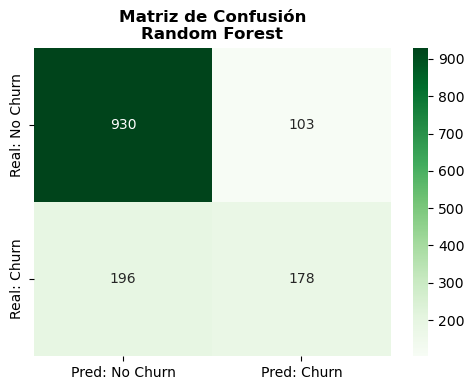

In [59]:
# Confusion matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred: No Churn", "Pred: Churn"],
            yticklabels=["Real: No Churn", "Real: Churn"])
plt.title("Matriz de Confusión\nRandom Forest", fontweight="bold")
plt.tight_layout()
plt.show()

### 6.3 Model Comparison

In [60]:
# Comparative table
resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_log), 4),
        round(accuracy_score(y_test, y_pred_rf), 4)
    ],
    "Precision": [
        round(precision_score(y_test, y_pred_log), 4),
        round(precision_score(y_test, y_pred_rf), 4)
    ],
    "Recall": [
        round(recall_score(y_test, y_pred_log), 4),
        round(recall_score(y_test, y_pred_rf), 4)
    ],
    "F1-Score": [
        round(f1_score(y_test, y_pred_log), 4),
        round(f1_score(y_test, y_pred_rf), 4)
    ],
    "Train Accuracy": [
        round(log_model.score(X_train_scaled, y_train), 4),
        round(rf_model.score(X_train, y_train), 4)
    ]
})

print(resultados.to_string(index=False))

             Modelo  Accuracy  Precision  Recall  F1-Score  Train Accuracy
Regresión Logística    0.8010     0.6556  0.5294    0.5858          0.8075
      Random Forest    0.7875     0.6335  0.4759    0.5435          0.9977


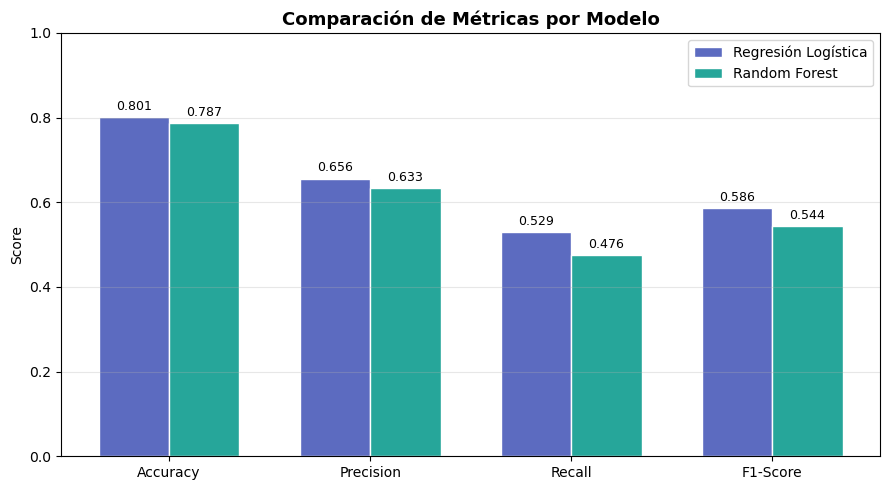

In [61]:
# Metrics Comparison Chart
metricas = ["Accuracy", "Precision", "Recall", "F1-Score"]
log_vals = [
    accuracy_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_log)
]
rf_vals = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, log_vals, width, label="Regresión Logística", color="# 5C6BC0", edgecolor="white")
bars2 = ax.bar(x + width/2, rf_vals,  width, label="Random Forest",        color="# 26A69A", edgecolor="white")

ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylabel("Score")
ax.set_title("Comparación de Métricas por Modelo", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

<div style="background: #fafafa; border: 1px solid #e0e0e0; border-radius: 10px; padding: 20px 24px; margin: 4px 0;">

**📊 Comparison table of results:**

| Model | Accuracy | Precision | Recall | F1-Score | Train Acc. |
|---|:---:|:---:|:---:|:---:|:---:|
| Logistic Regression | 0.801 | 0.656 | 0.529 | 0.586 | 0.808 |
| Random Forest | 0.788 | 0.636 | 0.468 | 0.539 | **0.998** |

</div>

<div style="display:flex; gap:12px; margin-top:12px;">
<div style="flex:1; background:#e8f5e9; border-radius:8px; padding:14px 16px; border-top: 3px solid #388e3c;">
<strong>✅ Logistic Regression — Recommended Model</strong><br>
<span style="font-size:0.9em; line-height:1.7;">Better Recall (0.53) and F1-Score (0.59). Train ≈ Test → <strong>without overfitting</strong>. Ideal for production due to its interpretability and generalization capacity.</span>
</div>
<div style="flex:1; background:#ffebee; border-radius:8px; padding:14px 16px; border-top: 3px solid #c62828;">
<strong>⚠️ Random Forest — Overfitting Detected</strong><br>
<span style="font-size:0.9em; line-height:1.7;">Train Accuracy 99.8% vs Test 78.8% → the model memorizes the training data. To fix it: adjust <code>max_depth</code>, <code>min_samples_leaf</code> and <code>max_features</code>.</span>
</div>
</div>

> 💡 **Why is Recall the priority metric?** In churn, the cost of not detecting a customer who is leaving (false negative) is much greater than that of contacting one who was not going to cancel (false positive).

---
## 📋 7. Importance of Variables

We analyze which variables contribute most to the prediction in each model. This interpretation is key to translating technical results into **concrete business decisions**.

### 7.1 Coefficients — Logistic Regression

In logistic regression, the coefficients indicate the direction and intensity of the effect of each variable on the probability of churn:
- **Positive coefficient** → increases the probability of cancellation
- **Negative coefficient** → reduces the probability of cancellation
- **Greater magnitude** → greater impact

In [62]:
# We extract coefficients and order them
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
}).sort_values("Coeficiente", ascending=False)

print("Top 5 variables que AUMENTAN la probabilidad de Churn:")
print(coef_df.head(5).to_string(index=False))

print("\nTop 5 variables que REDUCEN la probabilidad de Churn:")
print(coef_df.tail(5).to_string(index=False))

Top 5 variables que AUMENTAN la probabilidad de Churn:
                    Variable  Coeficiente
 InternetService_Fiber optic     0.636673
                 Cargo_Total     0.616979
             StreamingTV_Yes     0.236944
             Factura_Digital     0.181212
Metodo_Pago_Electronic check     0.167733

Top 5 variables que REDUCEN la probabilidad de Churn:
         Variable  Coeficiente
Contract_One year    -0.290086
  Cuentas_Diarias    -0.298877
    Cargo_Mensual    -0.357896
Contract_Two year    -0.565588
 Antiguedad_Meses    -1.319423


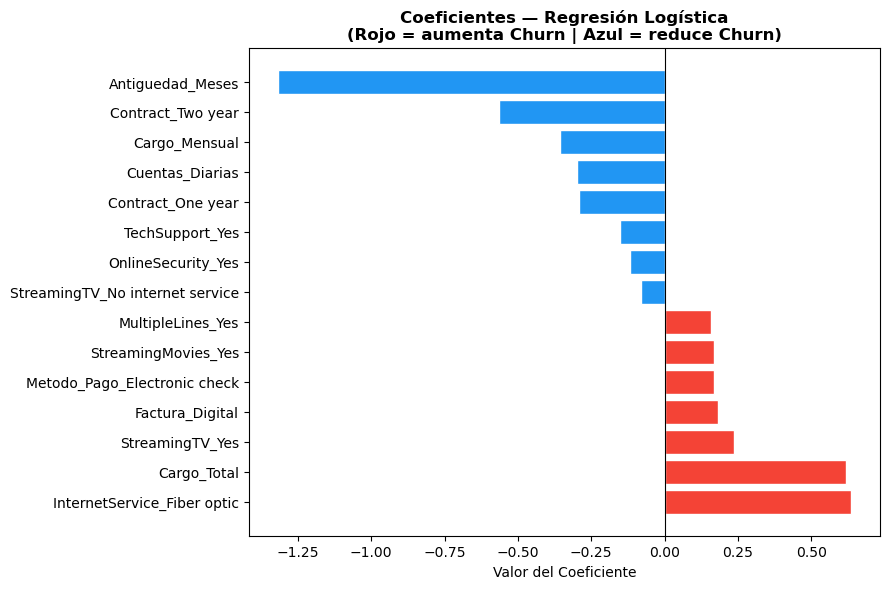

In [63]:
# Coefficient display
fig, ax = plt.subplots(figsize=(9, 6))
top_n = 15
top_coef = pd.concat([coef_df.head(7), coef_df.tail(8)])
colors = ["# F44336" if v > 0 else "#2196F3" for v in top_coef["Coefficient"]]
ax.barh(top_coef["Variable"], top_coef["Coeficiente"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coeficientes — Regresión Logística\n(Rojo = aumenta Churn | Azul = reduce Churn)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Valor del Coeficiente")
plt.tight_layout()
plt.show()

<div style="background: #e8eaf6; border-radius: 8px; padding: 16px 20px; margin: 4px 0;">
<strong>🔍 Most influential variables (Logistic Regression):</strong>
<table style="margin-top:10px; width:100%; border-collapse:collapse; font-size:0.9em;">
<tr style="background:#3949ab; color:white;">
<th style="padding:8px 12px; text-align:left;">Variable</th>
<th style="padding:8px 12px; text-align:center;">Coefficient</th>
<th style="padding:8px 12px;">Interpretation</th>
</tr>
<tr style="background:#ffebee;">
<td style="padding:8px 12px;"><code>Age_Months</code></td>
<td style="padding:8px 12px; text-align:center; color:#c62828; font-weight:bold;">−1.32</td>
<td style="padding:8px 12px;">Most protective factor: more months = much less risk of churn</td>
</tr>
<tr style="background:#fce4ec;">
<td style="padding:8px 12px;"><code>Contract_Two year</code></td>
<td style="padding:8px 12px; text-align:center; color:#c62828; font-weight:bold;">−0.57</td>
<td style="padding:8px 12px;">Long contracts considerably reduce churn</td>
</tr>
<tr style="background:#fff8e1;">
<td style="padding:8px 12px;"><code>InternetService_Fiber optic</code></td>
<td style="padding:8px 12px; text-align:center; color:#e65100; font-weight:bold;">+0.64</td>
<td style="padding:8px 12px;">Fiber optics increase risk — possibly due to perceived high cost</td>
</tr>
<tr style="background:#fff8e1;">
<td style="padding:8px 12px;"><code>Total_Charge</code></td>
<td style="padding:8px 12px; text-align:center; color:#e65100; font-weight:bold;">+0.62</td>
<td style="padding:8px 12px;">Greater accumulated spending increases risk (correlated with seniority)</td>
</tr>
</table>
</div>

### 7.2 Importance of Variables — Random Forest

Random Forest measures the importance of each variable by how much it contributes to **reducing impurity** (Gini) in the trees. The higher the value, the more determining the variable is for prediction.

In [64]:
# Importances of Random Forest
importances = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values("Importancia", ascending=False)

print("Top 10 variables más importantes (Random Forest):")
print(importances.head(10).to_string(index=False))

Top 10 variables más importantes (Random Forest):
                    Variable  Importancia
                 Cargo_Total     0.170688
            Antiguedad_Meses     0.157395
               Cargo_Mensual     0.139050
             Cuentas_Diarias     0.112652
Metodo_Pago_Electronic check     0.040510
 InternetService_Fiber optic     0.035557
           Contract_Two year     0.031862
                 gender_Male     0.025934
             Factura_Digital     0.025137
           Contract_One year     0.021389


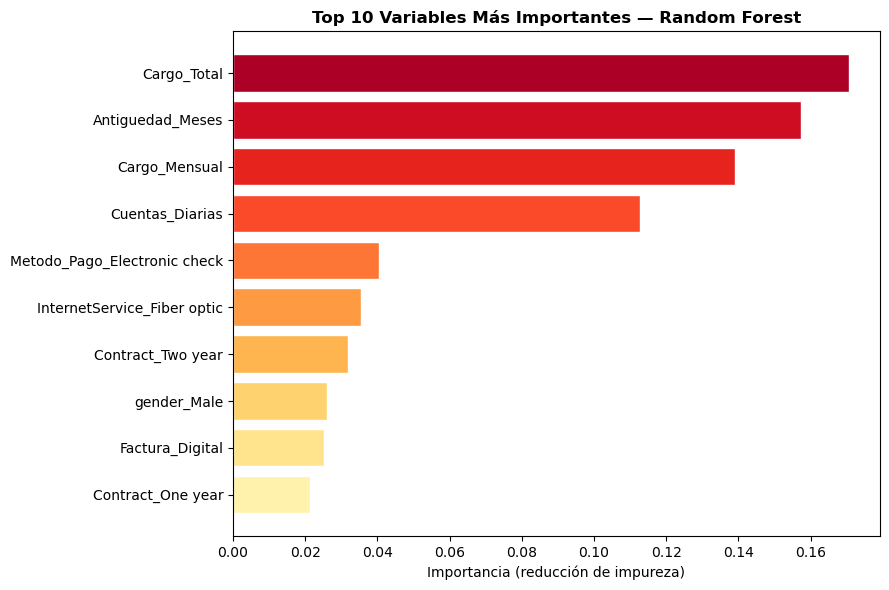

In [65]:
# Display
fig, ax = plt.subplots(figsize=(9, 6))
top10 = importances.head(10)
palette = sns.color_palette("YlOrRd_r", len(top10))
ax.barh(top10["Variable"][::-1], top10["Importancia"][::-1], color=palette[::-1], edgecolor="white")
ax.set_title("Top 10 Variables Más Importantes — Random Forest", fontsize=12, fontweight="bold")
ax.set_xlabel("Importancia (reducción de impureza)")
plt.tight_layout()
plt.show()

<div style="background: #e8f5e9; border-radius: 8px; padding: 16px 20px; margin: 4px 0;">
<strong>🌳 Most important variables (Random Forest):</strong>
<table style="margin-top:10px; width:100%; border-collapse:collapse; font-size:0.9em;">
<tr style="background:#2e7d32; color:white;">
<th style="padding:8px 12px; text-align:left;">Variable</th>
<th style="padding:8px 12px; text-align:center;">Importance</th>
<th style="padding:8px 12px;">Insight</th>
</tr>
<tr><td style="padding:8px 12px;"><code>Total_Charge</code></td><td style="padding:8px 12px; text-align:center; font-weight:bold;">17.0%</td><td style="padding:8px 12px;">Most discriminating variable of the model</td></tr>
<tr style="background:#f1f8e9;"><td style="padding:8px 12px;"><code>Seniority_Months</code></td><td style="padding:8px 12px; text-align:center; font-weight:bold;">15.7%</td><td style="padding:8px 12px;">Confirms that permanence protects against churn</td></tr>
<tr><td style="padding:8px 12px;"><code>Monthly_Charge</code></td><td style="padding:8px 12px; text-align:center; font-weight:bold;">14.0%</td><td style="padding:8px 12px;">High costs directly impact the decision to cancel</td></tr>
<tr style="background:#f1f8e9;"><td style="padding:8px 12px;"><code>Daily_Accounts</code></td><td style="padding:8px 12px; text-align:center; font-weight:bold;">11.2%</td><td style="padding:8px 12px;">Proxy of the daily cost perceived by the customer</td></tr>
<tr><td style="padding:8px 12px;"><code>Electronic_Payment_Method</code></td><td style="padding:8px 12px; text-align:center; font-weight:bold;">4.1%</td><td style="padding:8px 12px;">Payment method as a risk profile indicator</td></tr>
</table>
</div>

---
## 🏁 8. Conclusions and Retention Strategies

### 8.1 Main Cancellation Factors

The three approaches used—Pearson correlation, Logistic Regression coefficients, and Random Forest variable importance—**consistently agree** on the following determining factors:

| Factor | Address | Correlation | Coef. LR | RF Importance |
|---|:---:|:---:|:---:|:---:|
| **Client seniority** | ↓ Reduce churn | −0.35 | −1.32 | 15.7% |
| **Long-term contract** | ↓ Reduce churn | — | −0.57 | 5.4% |
| **Monthly charge** | ↑ Churn increases | +0.19 | — | 14.0% |
| **Fiber Optic Internet** | ↑ Churn increases | — | +0.64 | 3.5% |
| **Payment by electronic check** | ↑ Churn increases | — | +0.17 | 4.1% |

---

### 8.2 Recommended Retention Strategies

#### 🎯 Strategy 1 — Support Program for New Clients
The first months are the period of greatest risk. It is recommended:
- **Progressive discounts** during the first 6–12 months of stay.
- **Personalized monitoring** with active onboarding (calls, tutorials, priority support).
- Use of the **predictive model** to identify new customers with a high risk score and activate proactive campaigns before they cancel.

#### 💰 Strategy 2 — Review of the Value Proposition for Fiber Optic
Customers with fiber optic internet have a higher probability of churn, possibly due to the perception of high cost compared to the value received:
- Offer **combined plans** (fiber + additional services) with a better price-value ratio.
- Price benchmarking against competition and rate adjustment.

#### 📄 Strategy 3 — Incentives to Migrate to Long-Term Contracts
Monthly contracts are the contractual type with the highest churn:
- **Discounts for annual or biannual contract** (e.g. 2 months discounted when renewing for 2 years).
- **Exclusive benefits** for permanence: priority support, free upgrades.

#### 📊 Strategy 4 — Implementation of the Model in Production
- Deploy the **Logistic Regression** model as a monthly scoring engine.
- Define a risk threshold (e.g. probability > 0.60) to activate retention campaigns.
- Establish a quarterly **monitoring and retraining** cycle with updated data.

---

### 8.3 General Conclusion

<div style="background: linear-gradient(135deg, #1b5e20, #2e7d32); color: white; border-radius: 10px; padding: 24px 28px; margin-top: 8px;">

The analysis revealed that customer churn at Telecom

The models developed allow us to anticipate with good capacity which clients present the greatest risk. **Logistic Regression** is the recommended model for production due to its excellent generalization (without overfitting), its better Recall compared to Random Forest, and its high interpretability — an essential condition to justify business decisions.

The practical application of this pipeline can proactively reduce churn, improving **Customer Lifetime Value** and the sustained profitability of Telecom X.

</div>